In [9]:
%matplotlib inline

from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pandas_datareader.data as web
from pyfinance.ols import PandasRollingOLS
import yfinance as yf
from talib import RSI, BBANDS, MACD

Matplotlib is building the font cache; this may take a moment.


In [13]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

In [57]:
df = yf.download("WTM.AX", start="2026-01-01", end="2026-08-01")
df["Close"]

[*********************100%***********************]  1 of 1 completed


Ticker,WTM.AX
Date,
2026-01-02,0.580
2026-01-05,0.570
2026-01-06,0.555
2026-01-07,0.560
2026-01-08,0.540
...,...
2026-07-27,0.490
2026-07-28,0.490
2026-07-29,0.470


In [58]:
up, mid, low = BBANDS(df['Close']['WTM.AX'].to_numpy(), timeperiod=21, nbdevup=2, nbdevdn=2, matype=0)

In [59]:
rsi = RSI(df['Close']['WTM.AX'].to_numpy(), timeperiod=14)

In [60]:
macd, macdsignal, macdhist = MACD(df['Close']['WTM.AX'].to_numpy(), fastperiod=12, slowperiod=26, signalperiod=9)

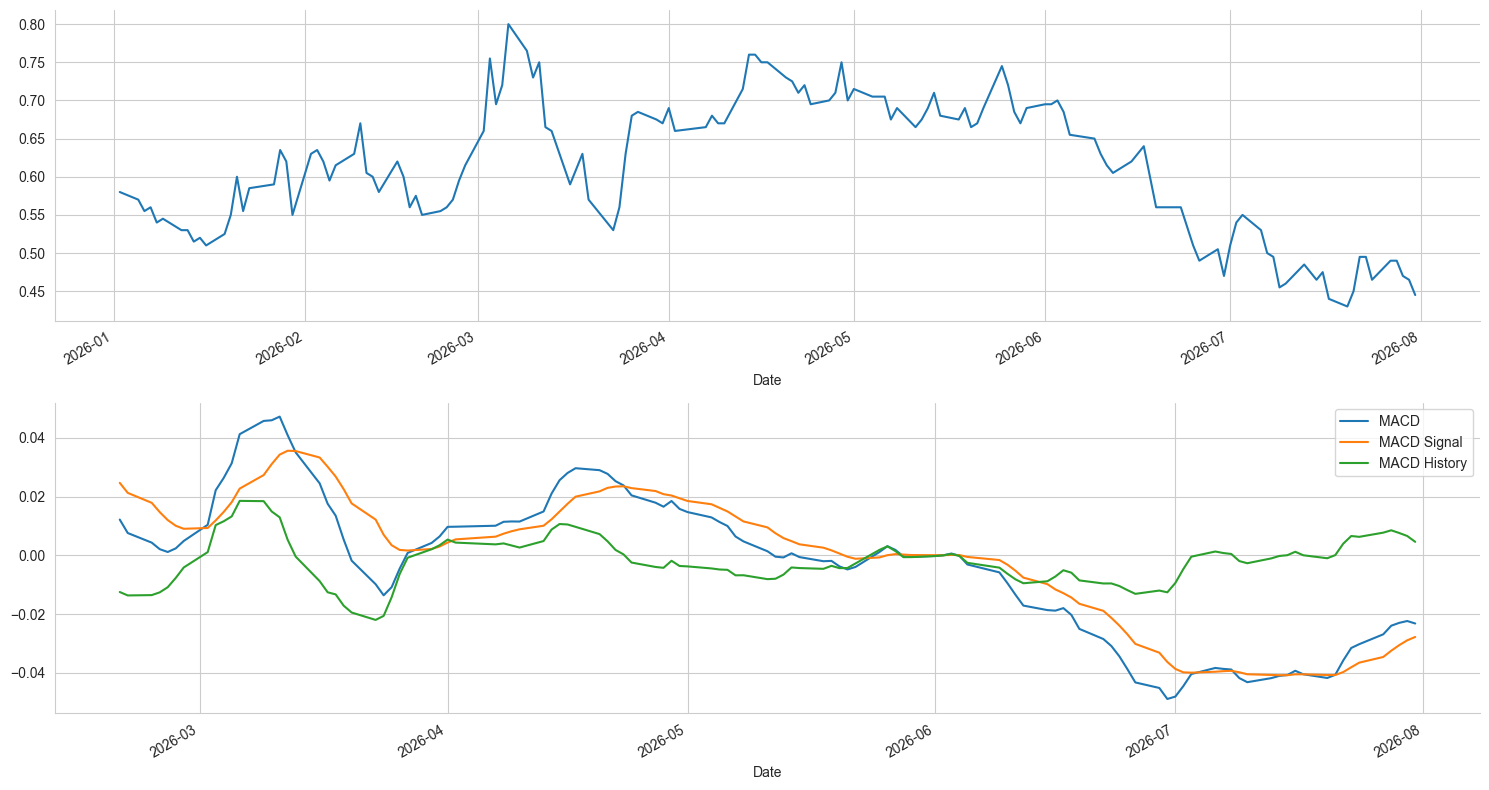

In [ ]:
macd_data = pd.DataFrame({'WTM.AX': df['Close']['WTM.AX'], 
                          'MACD': macd, 'MACD Signal': macdsignal, 'MACD History': macdhist})

fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
macd_data['WTM.AX'].plot(ax=axes[0])
macd_data.drop('WTM.AX', axis=1).plot(ax=axes[1])
fig.tight_layout()
sns.despine();

In [62]:
data = pd.DataFrame({'WTM.AX': df['Close']['WTM.AX'], 'BB Up': up, 'BB Mid': mid, 'BB down': low, 'RSI': rsi, 'MACD': macd})

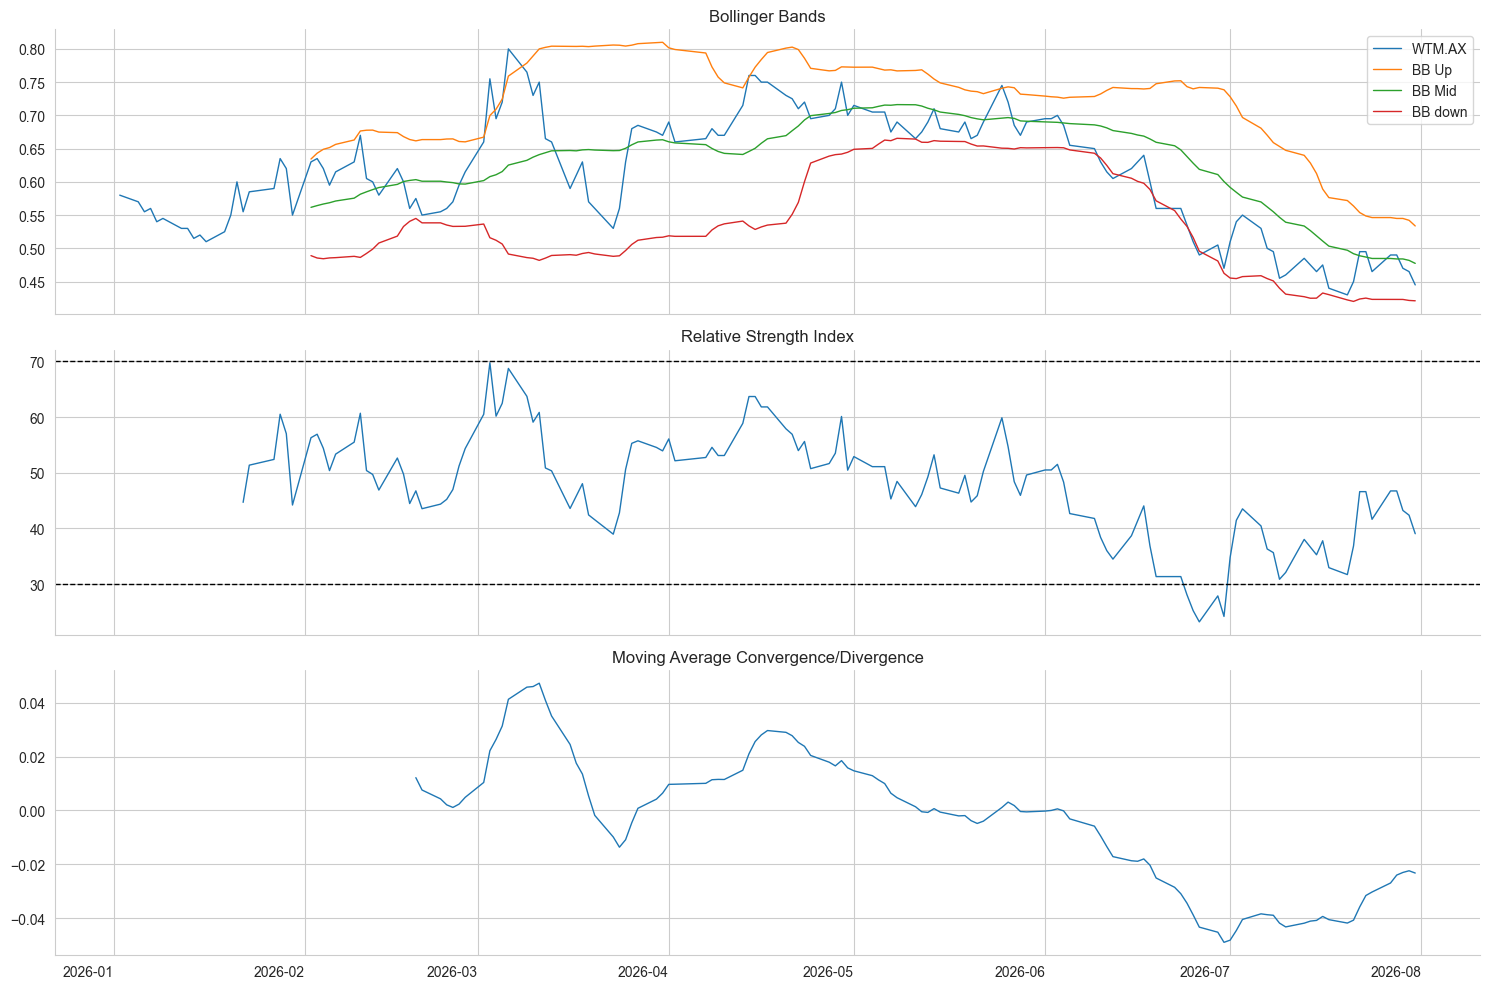

In [63]:
fig, axes= plt.subplots(nrows=3, figsize=(15, 10), sharex=True)
data.drop(['RSI', 'MACD'], axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data['RSI'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')
data.MACD.plot(ax=axes[2], lw=1, title='Moving Average Convergence/Divergence', rot=0)
axes[2].set_xlabel('')
fig.tight_layout()
sns.despine();